In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

n = 200

data = {
    "order_id": range(1001, 1001 + n),
    "city": np.random.choice(["Mumbai", "Delhi", "Bangalore", "Chennai"], size=n),
    "category": np.random.choice(["Electronics", "Clothing", "Groceries", "Furniture"], size=n),
    "order_value": np.random.randint(200, 5000, size=n).astype(float),
    "delivery_days": np.random.randint(1, 15, size=n).astype(float),
    "rating": np.random.choice([1, 2, 3, 4, 5, None], size=n)
}

missing_indices_order = np.random.choice(n, size=15, replace=False)
missing_indices_delivery = np.random.choice(n, size=10, replace=False)

data["order_value"][missing_indices_order] = np.nan
data["delivery_days"][missing_indices_delivery] = np.nan

data["order_value"][5] = 95000
data["order_value"][88] = 87000

df = pd.DataFrame(data)

print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (200, 6)


,order_id,city,category,order_value,delivery_days,rating
0,1001,Bangalore,Groceries,4191.0,11.0,4
1,1002,Chennai,Furniture,4923.0,12.0,1
2,1003,Mumbai,Groceries,4882.0,13.0,2
3,1004,Bangalore,Electronics,1848.0,13.0,1
4,1005,Bangalore,Furniture,1645.0,12.0,1


In [2]:
df.dtypes
df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage.round(2)

,0
order_id,0.0
city,0.0
category,0.0
order_value,7.0
delivery_days,5.0
rating,16.0


In [3]:
df.describe()

,order_id,order_value,delivery_days
count,200.000000,186.000000,190.000000
mean,1100.500000,3707.134409,7.810526
std,57.879185,9238.438378,4.075465
min,1001.000000,204.000000,1.000000
25%,1050.750000,1512.000000,4.000000
50%,1100.500000,2934.000000,8.000000
75%,1150.250000,3987.500000,12.000000
max,1200.000000,95000.000000,14.000000


histogram

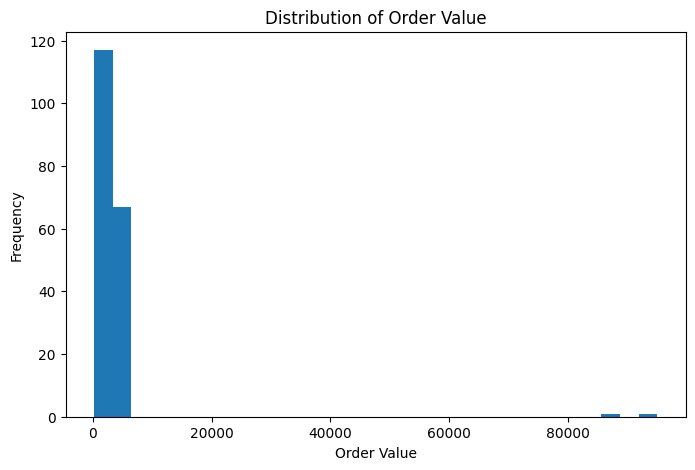

In [4]:
plt.figure(figsize=(8,5))
plt.hist(df["order_value"], bins=30)

plt.title("Distribution of Order Value")
plt.xlabel("Order Value")
plt.ylabel("Frequency")

plt.show()

box plot

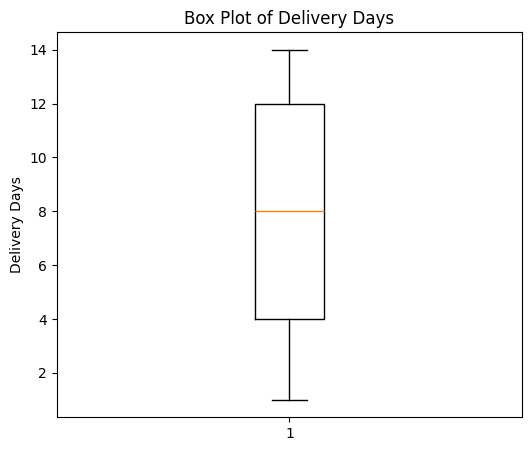

In [5]:
plt.figure(figsize=(6,5))
plt.boxplot(df["delivery_days"].dropna())

plt.title("Box Plot of Delivery Days")
plt.ylabel("Delivery Days")

plt.show()

In [6]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix


,order_id,order_value,delivery_days
order_id,1.000000,-0.095503,0.004858
order_value,-0.095503,1.000000,0.141660
delivery_days,0.004858,0.141660,1.000000


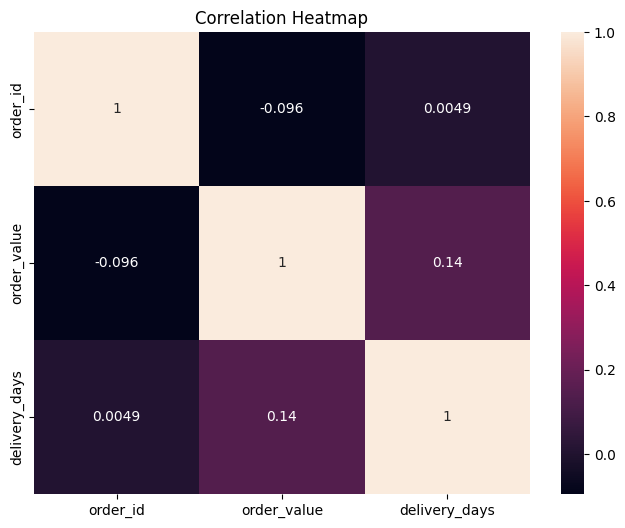

In [9]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True)
plt.title("Correlation Heatmap")
plt.show()